In [36]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Any, cast
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig

In [37]:
load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

In [38]:
class JokeState(TypedDict):
    
    topic: str
    joke: str
    explanation: str

In [39]:
def generate_joke(state: JokeState):
    prompt = f"Generate the short explanation about give topic, Topic: {state['topic']}"
    
    response: Any = llm.invoke(prompt)
    
    return {'joke': response}

In [40]:
def generate_explanation(state: JokeState):
    
    prompt = f'Write an example for the topic - {state['joke']}'
    response: Any = llm.invoke(prompt).content
    
    return {"explanation": response}

In [41]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

ckeckpointer = InMemorySaver()

workflow = graph.compile(checkpointer=ckeckpointer)

In [42]:
config1 = RunnableConfig(configurable= {'thread_id': '1'})
workflow.invoke({"topic": "Applied AI Engineer"}, config=config1)

{'topic': 'Applied AI Engineer',
 'joke': AIMessage(content=[{'type': 'text', 'text': 'An **Applied AI Engineer** is a bridge between high-level machine learning research and practical, real-world business solutions. \n\nUnlike a Research Scientist who focuses on inventing new algorithms or architectures, an Applied AI Engineer focuses on **implementation**. Their core responsibility is to take pre-existing models (or fine-tune existing ones) and integrate them into scalable, robust, and production-ready software systems.\n\n### Key aspects of the role include:\n\n*   **Bridging Theory and Practice:** They translate abstract business requirements into functional AI features, such as recommendation engines, chatbots, fraud detection systems, or computer vision tools.\n*   **Engineering Focus:** A significant portion of their work involves MLOps—building the data pipelines, monitoring systems, and infrastructure (like APIs and cloud services) required to serve AI models reliably.\n*   **

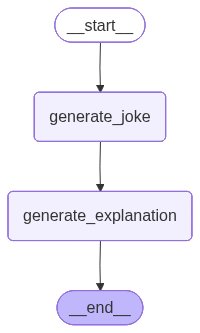

In [43]:
workflow

In [44]:
workflow.get_state(cast(Any, config1))

StateSnapshot(values={'topic': 'Applied AI Engineer', 'joke': AIMessage(content=[{'type': 'text', 'text': 'An **Applied AI Engineer** is a bridge between high-level machine learning research and practical, real-world business solutions. \n\nUnlike a Research Scientist who focuses on inventing new algorithms or architectures, an Applied AI Engineer focuses on **implementation**. Their core responsibility is to take pre-existing models (or fine-tune existing ones) and integrate them into scalable, robust, and production-ready software systems.\n\n### Key aspects of the role include:\n\n*   **Bridging Theory and Practice:** They translate abstract business requirements into functional AI features, such as recommendation engines, chatbots, fraud detection systems, or computer vision tools.\n*   **Engineering Focus:** A significant portion of their work involves MLOps—building the data pipelines, monitoring systems, and infrastructure (like APIs and cloud services) required to serve AI mode

In [45]:
list(workflow.get_state_history(cast(Any, config1)))

[StateSnapshot(values={'topic': 'Applied AI Engineer', 'joke': AIMessage(content=[{'type': 'text', 'text': 'An **Applied AI Engineer** is a bridge between high-level machine learning research and practical, real-world business solutions. \n\nUnlike a Research Scientist who focuses on inventing new algorithms or architectures, an Applied AI Engineer focuses on **implementation**. Their core responsibility is to take pre-existing models (or fine-tune existing ones) and integrate them into scalable, robust, and production-ready software systems.\n\n### Key aspects of the role include:\n\n*   **Bridging Theory and Practice:** They translate abstract business requirements into functional AI features, such as recommendation engines, chatbots, fraud detection systems, or computer vision tools.\n*   **Engineering Focus:** A significant portion of their work involves MLOps—building the data pipelines, monitoring systems, and infrastructure (like APIs and cloud services) required to serve AI mod

In [46]:
config2 = {"configurable": {"thread_id": '2'}}
workflow.invoke(cast(JokeState, {'topic': 'pasta'}), config=cast(Any, config2))

{'topic': 'pasta',
 'joke': AIMessage(content=[{'type': 'text', 'text': '**Pasta** is a staple food of traditional Italian cuisine, typically made from an unleavened dough of wheat flour (usually durum wheat semolina) mixed with water or eggs. The dough is formed into various shapes—such as spaghetti, penne, fusilli, or lasagna—and cooked by boiling. \n\nPasta is prized for its versatility; it serves as a "blank canvas" for a wide range of sauces, vegetables, meats, and cheeses. Whether served *al dente* (firm to the bite) or as a comforting baked dish, it is one of the most popular and globally recognized comfort foods.', 'extras': {'signature': 'EjQKMgERTTIP7MLDCPdlnJ0fSbhq+/XkScnqZzjC7C3QDYOkQltzCEcJBfQ/huWOHuvF7X5i'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f3875-07db-72a0-adef-ba3424cda7eb-0', tool_calls=[], invalid_tool_calls=[], usage_metadat

In [47]:
workflow.get_state(cast(Any, config1))

StateSnapshot(values={'topic': 'Applied AI Engineer', 'joke': AIMessage(content=[{'type': 'text', 'text': 'An **Applied AI Engineer** is a bridge between high-level machine learning research and practical, real-world business solutions. \n\nUnlike a Research Scientist who focuses on inventing new algorithms or architectures, an Applied AI Engineer focuses on **implementation**. Their core responsibility is to take pre-existing models (or fine-tune existing ones) and integrate them into scalable, robust, and production-ready software systems.\n\n### Key aspects of the role include:\n\n*   **Bridging Theory and Practice:** They translate abstract business requirements into functional AI features, such as recommendation engines, chatbots, fraud detection systems, or computer vision tools.\n*   **Engineering Focus:** A significant portion of their work involves MLOps—building the data pipelines, monitoring systems, and infrastructure (like APIs and cloud services) required to serve AI mode

In [48]:
list(workflow.get_state_history(cast(Any, config1)))

[StateSnapshot(values={'topic': 'Applied AI Engineer', 'joke': AIMessage(content=[{'type': 'text', 'text': 'An **Applied AI Engineer** is a bridge between high-level machine learning research and practical, real-world business solutions. \n\nUnlike a Research Scientist who focuses on inventing new algorithms or architectures, an Applied AI Engineer focuses on **implementation**. Their core responsibility is to take pre-existing models (or fine-tune existing ones) and integrate them into scalable, robust, and production-ready software systems.\n\n### Key aspects of the role include:\n\n*   **Bridging Theory and Practice:** They translate abstract business requirements into functional AI features, such as recommendation engines, chatbots, fraud detection systems, or computer vision tools.\n*   **Engineering Focus:** A significant portion of their work involves MLOps—building the data pipelines, monitoring systems, and infrastructure (like APIs and cloud services) required to serve AI mod

### Time Travel

In [51]:
workflow.get_state({
    "configurable": {"thread_id": "1", "checkpoint_id": "1f1795f6-4626-62d7-bfff-5ee87006055b"}
})

StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1795f6-4626-62d7-bfff-5ee87006055b'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-07-06T17:23:23.821947+00:00', parent_config=None, tasks=(PregelTask(id='aa2603e5-1153-b019-2853-cd34170e17a0', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'topic': 'Applied AI Engineer'}),), interrupts=())

In [52]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1795f6-4626-62d7-bfff-5ee87006055b"}})

{'topic': 'Applied AI Engineer',
 'joke': AIMessage(content=[{'type': 'text', 'text': 'An **Applied AI Engineer** is a bridge between the theoretical world of machine learning research and the practical needs of real-world business. \n\nWhile research scientists focus on developing new algorithms and pushing the boundaries of AI capabilities, the **Applied AI Engineer focuses on implementation**. Their primary goal is to take existing AI models—such as Large Language Models (LLMs), computer vision systems, or predictive analytics—and integrate them into functional, scalable, and reliable software products.\n\n### Key responsibilities include:\n*   **Model Integration:** Connecting pre-trained models (like GPT, BERT, or Stable Diffusion) to actual software applications via APIs or pipelines.\n*   **System Optimization:** Refining models (fine-tuning) to perform specific tasks with high accuracy and low latency.\n*   **MLOps:** Building the infrastructure to deploy, monitor, and maintain

In [53]:
list(workflow.get_state_history(cast(Any, config1)))

[StateSnapshot(values={'topic': 'Applied AI Engineer', 'joke': AIMessage(content=[{'type': 'text', 'text': 'An **Applied AI Engineer** is a bridge between the theoretical world of machine learning research and the practical needs of real-world business. \n\nWhile research scientists focus on developing new algorithms and pushing the boundaries of AI capabilities, the **Applied AI Engineer focuses on implementation**. Their primary goal is to take existing AI models—such as Large Language Models (LLMs), computer vision systems, or predictive analytics—and integrate them into functional, scalable, and reliable software products.\n\n### Key responsibilities include:\n*   **Model Integration:** Connecting pre-trained models (like GPT, BERT, or Stable Diffusion) to actual software applications via APIs or pipelines.\n*   **System Optimization:** Refining models (fine-tuning) to perform specific tasks with high accuracy and low latency.\n*   **MLOps:** Building the infrastructure to deploy, 

### Updating State of a LangGraph

In [56]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "your_checkpoint_id", "checkpoint_ns": ""}}, {'topic': 'Applied AI Engineer'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1795fc-3444-6026-8000-3054e1d6ef52'}}

In [57]:
list(workflow.get_state_history(cast(Any, config1)))

[StateSnapshot(values={'topic': 'Applied AI Engineer'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1795fc-3444-6026-8000-3054e1d6ef52'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-07-06T17:26:03.008003+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': 'your_checkpoint_id'}}, tasks=(PregelTask(id='d739d572-48f2-2d30-831c-077b32972b01', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'GenAI Engineer'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1795fb-fbb7-6ec6-8000-482d8a86f8ff'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-07-06T17:25:57.078599+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint

In [58]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1795f6-4626-62d7-bfff-5ee87006055b"}})

{'topic': 'Applied AI Engineer',
 'joke': AIMessage(content=[{'type': 'text', 'text': 'An **Applied AI Engineer** is a professional who focuses on taking cutting-edge artificial intelligence research and putting it into practice to solve real-world business or technical problems.\n\nWhile a traditional AI Researcher might spend their time developing new algorithms or mathematical models, an **Applied AI Engineer** focuses on:\n\n*   **Integration:** Embedding AI models into functional software applications, products, or workflows.\n*   **Optimization:** Refining pre-existing models to be faster, more cost-effective, and more accurate for specific use cases.\n*   **Infrastructure:** Building the pipelines required to feed data into models, deploy them at scale, and monitor their performance in production (often referred to as MLOps).\n*   **Problem Solving:** Translating complex business requirements into tangible AI solutions, such as implementing a chatbot for customer service, creati

In [59]:
list(workflow.get_state_history(cast(Any, config1)))

[StateSnapshot(values={'topic': 'Applied AI Engineer', 'joke': AIMessage(content=[{'type': 'text', 'text': 'An **Applied AI Engineer** is a professional who focuses on taking cutting-edge artificial intelligence research and putting it into practice to solve real-world business or technical problems.\n\nWhile a traditional AI Researcher might spend their time developing new algorithms or mathematical models, an **Applied AI Engineer** focuses on:\n\n*   **Integration:** Embedding AI models into functional software applications, products, or workflows.\n*   **Optimization:** Refining pre-existing models to be faster, more cost-effective, and more accurate for specific use cases.\n*   **Infrastructure:** Building the pipelines required to feed data into models, deploy them at scale, and monitor their performance in production (often referred to as MLOps).\n*   **Problem Solving:** Translating complex business requirements into tangible AI solutions, such as implementing a chatbot for cus

## Fault Tolerance and Recovery

In [60]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [61]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [77]:
# 2. Define Steps

def step_1(state: CrashState):
    print("Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState):
    print("Step 2 hanging....")
    print("Now Manually interrup from the notebook toolbar")
    time.sleep(5)
    
    return {state["input"]: "Step 2 Done", "step1": "Done", "step2": "Done"}

def step_3(state: CrashState):
    print("Step 3 Executed")
    
    return {state["input"]: "Done"}

In [78]:
# 3. Build the graph
builder = StateGraph(CrashState)

builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")

builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()

workflow2 = builder.compile(checkpointer=checkpointer)


In [80]:
try:
    print("Running graph: Please manually interrupt during step 2...")
    workflow2.invoke(cast(CrashState, {"input": "start"}), config={"configurable": {"thread_id": "thread-1"}})
except KeyboardInterrupt:
    print("Kernel manually interrupted (Crash Simulated).")

Running graph: Please manually interrupt during step 2...
Step 1 executed
Step 2 hanging....
Now Manually interrup from the notebook toolbar
Step 3 Executed


In [81]:

# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = workflow2.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...

✅ Final State: {'input': 'start', 'step1': 'Done', 'step2': 'Done'}


In [82]:
list(workflow2.get_state_history({
    "configurable": {"thread_id": 'thread-1'}
}))

[StateSnapshot(values={'input': 'start', 'step1': 'Done', 'step2': 'Done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f179609-cbef-6762-8006-3c106b22d415'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-07-06T17:32:07.877821+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f179609-cbe7-625f-8005-f2f521632cfe'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'Done', 'step2': 'Done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f179609-cbe7-625f-8005-f2f521632cfe'}}, metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-07-06T17:32:07.874415+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f179609-9c29-66e5-8004-2bf297e853c0'}}, tasks=(PregelTask(id='f69d9f57-efd2-9f20-3cdb-4473ec26a4f